In [23]:
import sys
sys.path.append('../src')

In [24]:
import numpy as np
import pandas as pd
from scipy.stats import norm

In [25]:
time = 200
d_mu = 100
d_sigma = 25
demand = np.maximum(np.random.normal(d_mu, d_sigma, time).round(0).astype(int), 0)

In [ ]:
L, R, alpha = 4, 1, 0.95
z = norm.ppf(alpha)
x_std = np.sqrt(L + R) * d_sigma
Ss = np.round(x_std * z).astype(int)
Cs = 0.5 * d_mu * R
Is = d_mu * L
S = Ss + 2 * Cs + Is

In [27]:
hand = np.zeros(time, dtype=int)
transit = np.zeros((time, L + 1), dtype=int)

In [28]:
hand[0] = S - demand[0]
transit[1, -1] = demand[0]

In [29]:
stockout_period = np.full(time, False, dtype=bool)
stockout_cycle = []

In [30]:
for t in range(1, time):
    if transit[t - 1, 0] > 0:
        stockout_cycle.append(stockout_period[t - 1])
    hand[t] = hand[t - 1] - demand[t] + transit[t - 1, 0]
    stockout_period[t] = hand[t] < 0
    # hand[t] = max(hand[t], 0)  # Uncomment to prevent negative inventory: lost sales rather than backorders
    transit[t, :-1] = transit[t - 1, 1:]
    if 0 == t % R:
        net = hand[t] + transit[t].sum()
        transit[t, L] = S - net
        

In [31]:
df = pd.DataFrame({
    "demand": demand,
    "on-hand": hand,
    "in-transit": list(transit),
})
df = df.iloc[R + L:, :]
df.head()

,demand,on-hand,in-transit
1,89,-62,[89]
2,98,-71,[212]
3,96,45,[96]
4,79,62,[79]
5,83,58,[83]


<Axes: title={'center': 'Inventory policy (1, 141.0)'}>

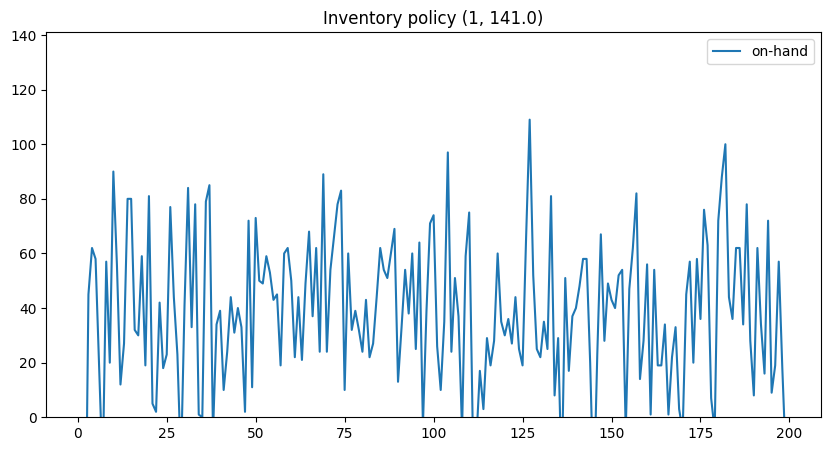

In [32]:
df["on-hand"].plot(title=f"Inventory policy ({R}, {S})", figsize=(10, 5), ylim=(0, S), legend=True)

In [33]:
print("Alpha:", alpha * 100, "%")
SL_alpha = 1 - sum(stockout_cycle) / len(stockout_cycle)
print("Service level:", SL_alpha * 100, "%")
SL_period = 1 - sum(stockout_period) / len(stockout_period)
print("Service level (periods):", SL_period * 100, "%")

Alpha: 95.0 %
Service level: 92.92929292929293 %
Service level (periods): 92.5 %
